# Experiment 3 — Mirror: Opposite-Direction Confounding

**Goal:** Expose the asymmetric failure mode of `sig_slack` by running the Experiment 1
baseline setup with the hidden confounder biasing the estimate **downward** instead of upward.

Only `β_YA` is negated — the confounder still correlates with treatment in the same direction.
This keeps partial R² values identical to Exp 1, so bound validity (coverage, ρ) is a mirror
image.  But `sig_slack` tells a completely different story: the practitioner now _loses_
significance as the confounder grows, while in Exp 1 they stayed confident past the cliff.

**Setup**
- $D^* = X\beta_{DX} + A\beta_{DA} + \varepsilon_D$, $\quad D = \mathbf{1}[D^* > 0]$
- $Y = \tau D + X\beta_{YX} + A\beta_{YA} + \varepsilon_Y$
- $\tau_{\text{true}} = 1.0$
- $\beta_{DX} = \beta_{YX} = [0.5, 0.5, 0.5, 0.5, 0.5]$
- $\beta_{DA} = +0.5m$  (same direction as Exp 1)
- $\beta_{YA} = -0.5m$  ← negated: confounder now pushes $\hat{\tau}$ below $\tau_{\text{true}}$

The **four-panel figure** at the bottom of this notebook is the main result:
- Top row (bound validity): signed $\rho$ is a mirror image of Exp 1 — same cliff, opposite sign.
- Bottom row (practitioner view): `sig_slack` drops toward zero and goes negative, while in
  Exp 1 it rose monotonically.  The practitioner diagnostic sends opposite signals for the
  same underlying bound-violation event.

In [1]:
import sys
import os
sys.path.insert(0, os.path.join('..', 'src'))

import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from dgp import DGPConfig, generate_data
from loo_benchmark import loo_benchmark
from ovb_formula import compute_RV
from robustness_plot import plot_robustness_contour

plt.rcParams.update({'font.size': 12, 'figure.dpi': 120})

In [2]:
tau_true   = 1.0
n_trials   = 100

beta_dx    = 0.5
beta_yx    = 0.5

multipliers = np.linspace(0.5, 2.5, 50)

coverage        = []
mean_ovb        = []
mean_Bmax       = []
mean_RV         = []
mean_rho        = []
mean_signed_rho = []
p10_rho         = []
p90_rho         = []
p10_signed_rho  = []
p90_signed_rho  = []
mean_sig_slack  = []
mean_r2_ax      = []
last_trial_data = {}

for m_idx, multiplier in enumerate(multipliers):
    beta_da = +0.5 * multiplier   # same direction as Exp 1
    beta_ya = -0.5 * multiplier   # NEGATED: downward confounding

    covered         = 0
    ovb_vals        = []
    B_vals          = []
    rv_vals         = []
    rho_vals        = []
    signed_rho_vals = []
    sig_slack_vals  = []
    r2_ax_vals      = []

    for trial in range(n_trials):
        seed = m_idx * n_trials + trial

        config = DGPConfig(
            num_X=5, num_A=1,
            beta_dx=beta_dx, beta_da=beta_da,
            beta_yx=beta_yx, beta_ya=beta_ya,
            seed=seed,
        )
        Y, D, X, A = generate_data(config)

        short_fit = sm.OLS(Y, sm.add_constant(np.column_stack([D, X]))).fit()
        tau_short = short_fit.params[1]
        se_short  = short_fit.bse[1]

        loo_results, S2_full, B_max = loo_benchmark(Y, D, X)
        RV    = compute_RV(tau_short, S2_full)

        ovb = abs(tau_short - tau_true)
        ovb_vals.append(ovb)
        B_vals.append(B_max)
        rv_vals.append(RV)

        rho_vals.append(ovb / B_max if B_max > 0 else np.nan)

        # Negative: τ_short < τ_true, so signed_rho < 0
        signed_ovb = tau_short - tau_true
        signed_rho_vals.append(signed_ovb / B_max if B_max > 0 else np.nan)

        lower_ci = abs(tau_short) - 1.96 * se_short
        sig_slack_vals.append(lower_ci / B_max if B_max > 0 else np.nan)

        r2_ax_vals.append(sm.OLS(A[:, 0], sm.add_constant(X)).fit().rsquared)

        if ovb <= B_max:
            covered += 1

        last_trial_data[m_idx] = (tau_short, S2_full, loo_results)

    coverage.append(100.0 * covered / n_trials)
    mean_ovb.append(np.mean(ovb_vals))
    mean_Bmax.append(np.mean(B_vals))
    mean_RV.append(np.mean(rv_vals))
    mean_rho.append(np.nanmean(rho_vals))
    mean_signed_rho.append(np.nanmean(signed_rho_vals))
    p10_rho.append(np.nanpercentile(rho_vals, 10))
    p90_rho.append(np.nanpercentile(rho_vals, 90))
    p10_signed_rho.append(np.nanpercentile(signed_rho_vals, 10))
    p90_signed_rho.append(np.nanpercentile(signed_rho_vals, 90))
    mean_sig_slack.append(np.nanmean(sig_slack_vals))
    mean_r2_ax.append(np.nanmean(r2_ax_vals))

    print(f"m={multiplier:5.2f}  coverage={coverage[-1]:5.1f}%  "
          f"mean|OVB|={mean_ovb[-1]:.4f}  mean B_max={mean_Bmax[-1]:.4f}  "
          f"mean RV={mean_RV[-1]:.4f}  mean ρ={mean_rho[-1]:.3f}  "
          f"signed ρ={mean_signed_rho[-1]:.3f}  "
          f"sig_slack={mean_sig_slack[-1]:.3f}  R²(A|X)={mean_r2_ax[-1]:.4f}")

m= 0.50  coverage=100.0%  mean|OVB|=0.1041  mean B_max=0.3857  mean RV=0.3539  mean ρ=0.269  signed ρ=-0.262  sig_slack=2.049  R²(A|X)=0.0023
m= 0.54  coverage=100.0%  mean|OVB|=0.1226  mean B_max=0.3830  mean RV=0.3454  mean ρ=0.320  signed ρ=-0.320  sig_slack=2.008  R²(A|X)=0.0025
m= 0.58  coverage=100.0%  mean|OVB|=0.1284  mean B_max=0.3859  mean RV=0.3403  mean ρ=0.333  signed ρ=-0.333  sig_slack=1.977  R²(A|X)=0.0025
m= 0.62  coverage=100.0%  mean|OVB|=0.1602  mean B_max=0.3857  mean RV=0.3263  mean ρ=0.415  signed ρ=-0.415  sig_slack=1.893  R²(A|X)=0.0027
m= 0.66  coverage=100.0%  mean|OVB|=0.1830  mean B_max=0.3800  mean RV=0.3168  mean ρ=0.481  signed ρ=-0.481  sig_slack=1.857  R²(A|X)=0.0025
m= 0.70  coverage=100.0%  mean|OVB|=0.1825  mean B_max=0.3846  mean RV=0.3157  mean ρ=0.476  signed ρ=-0.476  sig_slack=1.835  R²(A|X)=0.0024
m= 0.74  coverage= 99.0%  mean|OVB|=0.2010  mean B_max=0.3840  mean RV=0.3064  mean ρ=0.524  signed ρ=-0.524  sig_slack=1.790  R²(A|X)=0.0028
m= 0.7

In [3]:
np.save('results/experiment_03_results.npy', {
    'multipliers':      np.array(multipliers),
    'coverage':         np.array(coverage),
    'mean_ovb':         np.array(mean_ovb),
    'mean_Bmax':        np.array(mean_Bmax),
    'mean_RV':          np.array(mean_RV),
    'mean_rho':         np.array(mean_rho),
    'mean_signed_rho':  np.array(mean_signed_rho),
    'p10_rho':          np.array(p10_rho),
    'p90_rho':          np.array(p90_rho),
    'p10_signed_rho':   np.array(p10_signed_rho),
    'p90_signed_rho':   np.array(p90_signed_rho),
    'mean_sig_slack':   np.array(mean_sig_slack),
    'mean_r2_ax':       np.array(mean_r2_ax),
}, allow_pickle=True)
print('Saved → results/experiment_03_results.npy')

Saved → results/experiment_03_results.npy


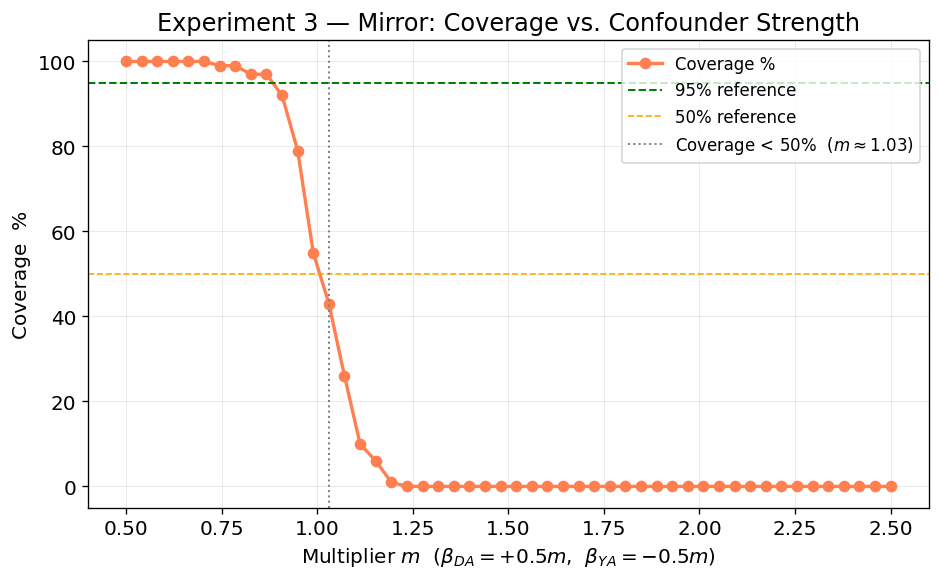

In [4]:
cliff_idx = next((i for i, c in enumerate(coverage) if c < 50), None)
cliff_m   = multipliers[cliff_idx] if cliff_idx is not None else None

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(multipliers, coverage, marker='o', linewidth=2, color='coral', label='Coverage %')
ax.axhline(95, linestyle='--', color='green',  linewidth=1.2, label='95% reference')
ax.axhline(50, linestyle='--', color='orange', linewidth=1.0, label='50% reference')
if cliff_m is not None:
    ax.axvline(cliff_m, linestyle=':', color='gray', linewidth=1.2,
               label=f'Coverage < 50%  ($m \\approx {cliff_m:.2f}$)')
ax.set_xlabel(r'Multiplier $m$  ($\beta_{DA}=+0.5m$,  $\beta_{YA}=-0.5m$)')
ax.set_ylabel('Coverage  %')
ax.set_title('Experiment 3 — Mirror: Coverage vs. Confounder Strength')
ax.set_ylim(-5, 105)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/experiment_03_mirror_coverage.png', bbox_inches='tight')
plt.show()

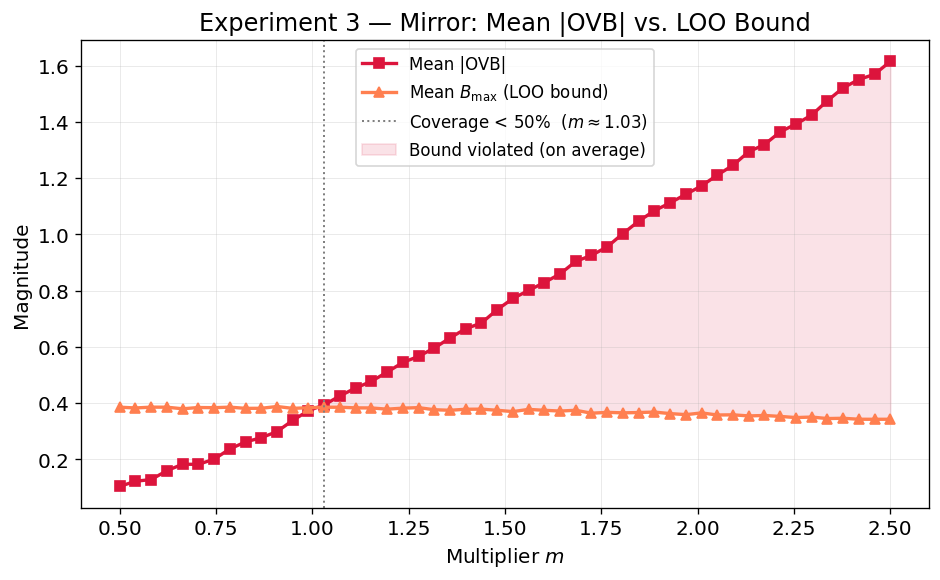

In [5]:
cliff_idx = next((i for i, c in enumerate(coverage) if c < 50), None)
cliff_m   = multipliers[cliff_idx] if cliff_idx is not None else None

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(multipliers, mean_ovb,  marker='s', linewidth=2, color='crimson',  label='Mean |OVB|')
ax.plot(multipliers, mean_Bmax, marker='^', linewidth=2, color='coral',    label=r'Mean $B_{\max}$ (LOO bound)')
if cliff_m is not None:
    ax.axvline(cliff_m, linestyle=':', color='gray', linewidth=1.2,
               label=f'Coverage < 50%  ($m \\approx {cliff_m:.2f}$)')
ovb_arr  = np.array(mean_ovb)
bmax_arr = np.array(mean_Bmax)
ax.fill_between(multipliers, ovb_arr, bmax_arr,
                where=(ovb_arr > bmax_arr), color='crimson', alpha=0.12,
                label='Bound violated (on average)')
ax.set_xlabel(r'Multiplier $m$')
ax.set_ylabel('Magnitude')
ax.set_title('Experiment 3 — Mirror: Mean |OVB| vs. LOO Bound')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/experiment_03_mirror_ovb_vs_bound.png', bbox_inches='tight')
plt.show()

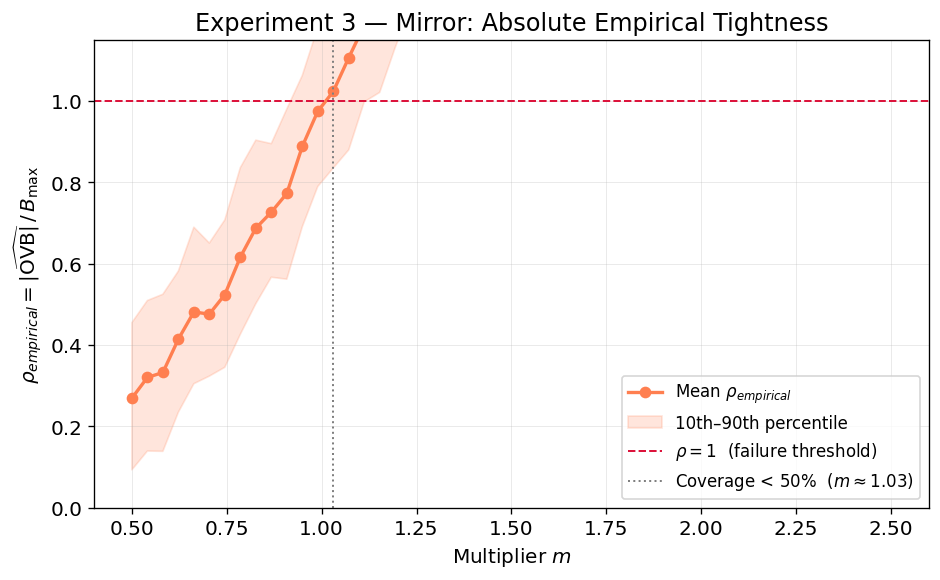

In [6]:
cliff_idx = next((i for i, c in enumerate(coverage) if c < 50), None)
cliff_m   = multipliers[cliff_idx] if cliff_idx is not None else None

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(multipliers, mean_rho, marker='o', linewidth=2, color='coral',
        label=r'Mean $\rho_{empirical}$')
ax.fill_between(multipliers, p10_rho, p90_rho, alpha=0.2, color='coral',
                label='10th–90th percentile')
ax.axhline(1.0, linestyle='--', color='crimson', linewidth=1.2,
           label=r'$\rho = 1$  (failure threshold)')
if cliff_m is not None:
    ax.axvline(cliff_m, linestyle=':', color='gray', linewidth=1.2,
               label=f'Coverage < 50%  ($m \\approx {cliff_m:.2f}$)')
ax.set_xlabel(r'Multiplier $m$')
ax.set_ylabel(r'$\rho_{empirical} = |\widehat{\mathrm{OVB}}| \,/\, B_{\max}$')
ax.set_title('Experiment 3 — Mirror: Absolute Empirical Tightness')
ax.set_ylim(0, 1.15)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/experiment_03_mirror_rho.png', bbox_inches='tight')
plt.show()

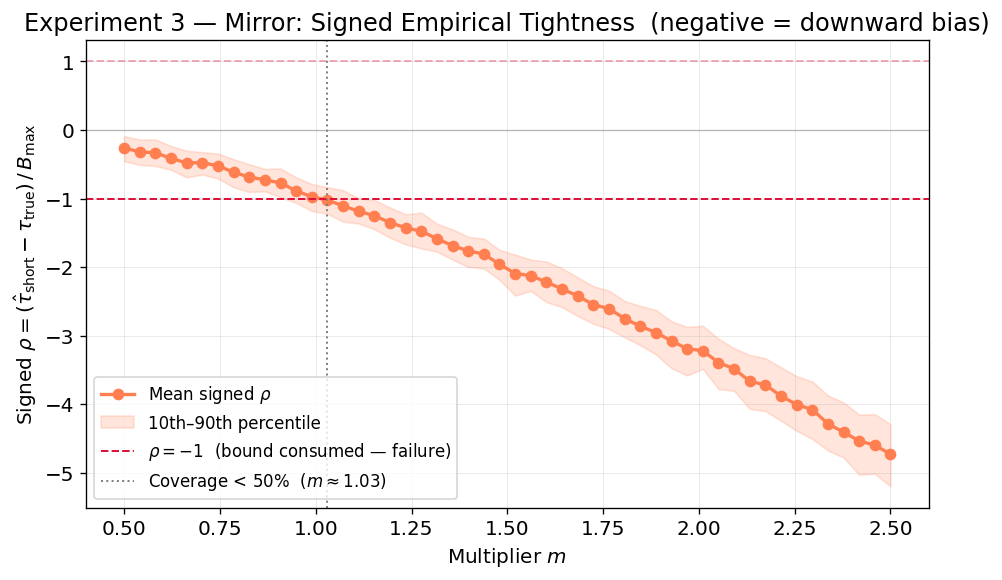

In [7]:
cliff_idx = next((i for i, c in enumerate(coverage) if c < 50), None)
cliff_m   = multipliers[cliff_idx] if cliff_idx is not None else None

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(multipliers, mean_signed_rho, marker='o', linewidth=2, color='coral',
        label=r'Mean signed $\rho$')
ax.fill_between(multipliers, p10_signed_rho, p90_signed_rho,
                alpha=0.2, color='coral', label='10th–90th percentile')
ax.axhline(-1.0, linestyle='--', color='crimson', linewidth=1.2,
           label=r'$\rho = -1$  (bound consumed — failure)')
ax.axhline(+1.0, linestyle='--', color='crimson', linewidth=1.2, alpha=0.35)
ax.axhline( 0.0, linestyle='-',  color='gray',    linewidth=0.8, alpha=0.5)
if cliff_m is not None:
    ax.axvline(cliff_m, linestyle=':', color='gray', linewidth=1.2,
               label=f'Coverage < 50%  ($m \\approx {cliff_m:.2f}$)')
ax.set_xlabel(r'Multiplier $m$')
ax.set_ylabel(
    r'Signed $\rho = (\hat{\tau}_{\mathrm{short}} - \tau_{\mathrm{true}}) \,/\, B_{\max}$'
)
ax.set_title('Experiment 3 — Mirror: Signed Empirical Tightness  (negative = downward bias)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/experiment_03_mirror_signed_rho.png', bbox_inches='tight')
plt.show()

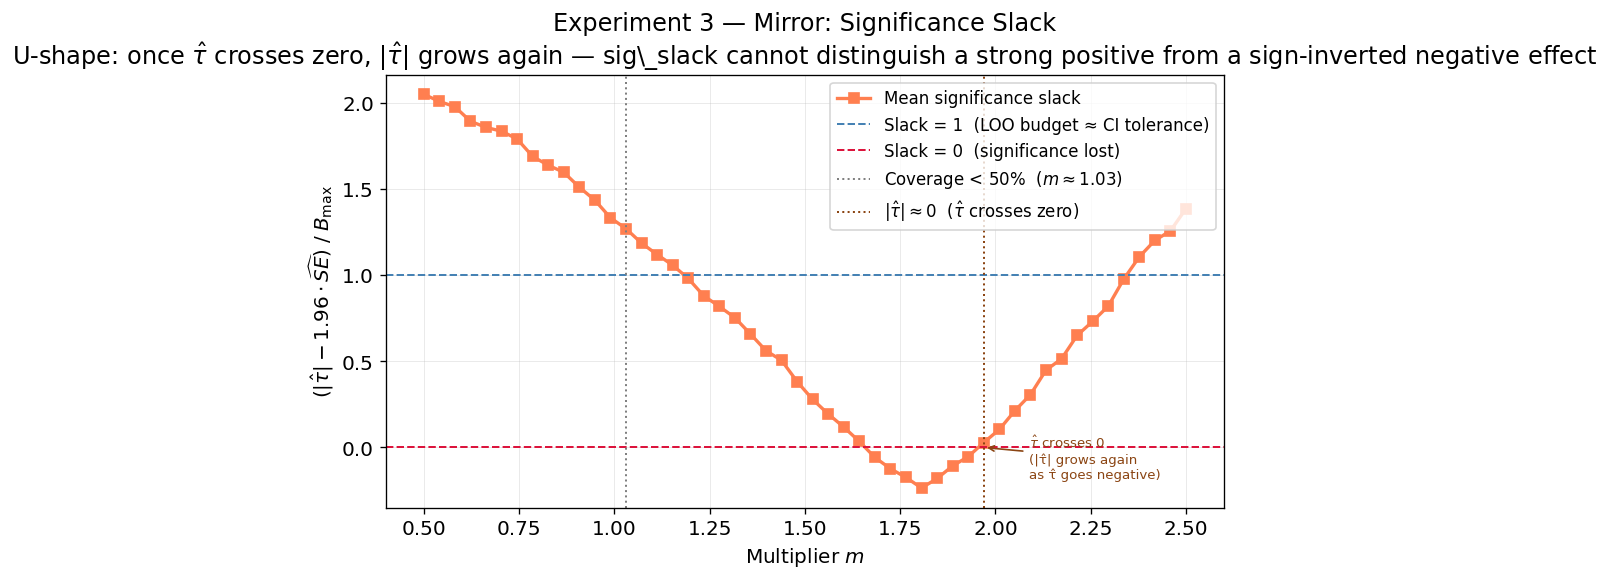

In [8]:
cliff_idx = next((i for i, c in enumerate(coverage) if c < 50), None)
cliff_m   = multipliers[cliff_idx] if cliff_idx is not None else None

# Find where |τ̂| ≈ 0 (τ̂ crosses zero) — bottom of the U-shape
tau_cross_idx = np.argmin(np.abs(mean_sig_slack))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(multipliers, mean_sig_slack, marker='s', linewidth=2, color='coral',
        label='Mean significance slack')
ax.axhline(1.0, linestyle='--', color='steelblue', linewidth=1.2,
           label='Slack = 1  (LOO budget ≈ CI tolerance)')
ax.axhline(0.0, linestyle='--', color='crimson',   linewidth=1.2,
           label='Slack = 0  (significance lost)')
if cliff_m is not None:
    ax.axvline(cliff_m, linestyle=':', color='gray', linewidth=1.2,
               label=f'Coverage < 50%  ($m \\approx {cliff_m:.2f}$)')
ax.axvline(multipliers[tau_cross_idx], linestyle=':', color='saddlebrown', linewidth=1.2,
           label=r'$|\hat{\tau}| \approx 0$  ($\hat{\tau}$ crosses zero)')
ax.annotate(r'$\hat{\tau}$ crosses 0' '\n(|τ̂| grows again\nas τ̂ goes negative)',
            xy=(multipliers[tau_cross_idx], 0),
            xytext=(multipliers[tau_cross_idx] + 0.12, -0.18),
            fontsize=8, color='saddlebrown',
            arrowprops=dict(arrowstyle='->', color='saddlebrown', lw=1.0))
ax.set_xlabel(r'Multiplier $m$')
ax.set_ylabel(r'$(|\hat{\tau}| - 1.96 \cdot \widehat{SE}) \;/\; B_{\max}$')
ax.set_title(
    'Experiment 3 — Mirror: Significance Slack\n'
    r'U-shape: once $\hat{\tau}$ crosses zero, $|\hat{\tau}|$ grows again — '
    r'sig\_slack cannot distinguish a strong positive from a sign-inverted negative effect'
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/experiment_03_mirror_sig_slack.png', bbox_inches='tight')
plt.show()

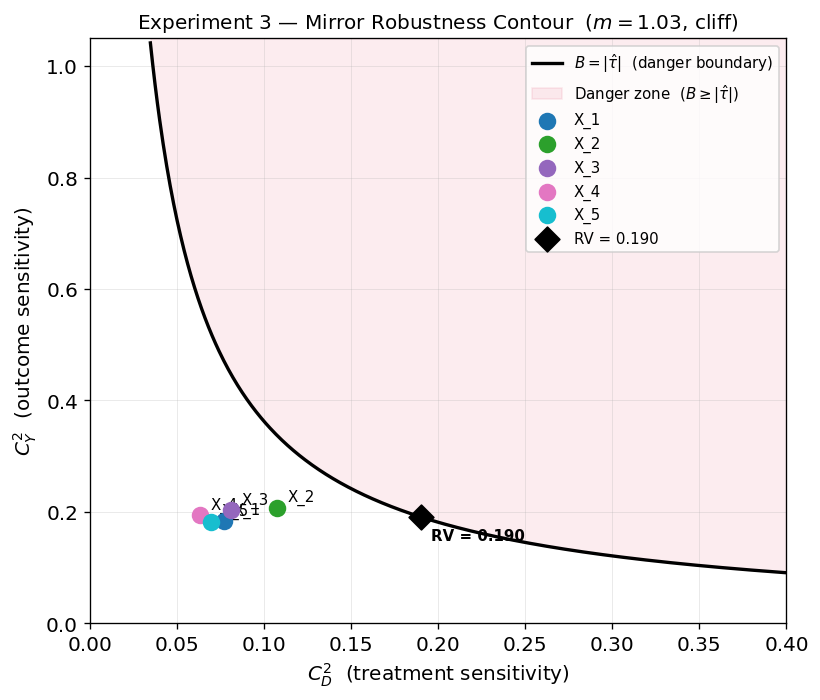

In [9]:
cliff_idx  = next((i for i, c in enumerate(coverage) if c < 50), len(multipliers) - 1)
cliff_m    = multipliers[cliff_idx]
tau_s, S2, loo_r = last_trial_data[cliff_idx]

fig, ax = plt.subplots(figsize=(7, 6))
plot_robustness_contour(
    tau_hat     = tau_s,
    S2          = S2,
    loo_results = loo_r,
    ax          = ax,
    title       = f'Experiment 3 — Mirror Robustness Contour  ($m = {cliff_m:.2f}$, cliff)',
)
plt.tight_layout()
plt.savefig('figures/experiment_03_mirror_contour.png', bbox_inches='tight')
plt.show()

### Contour plot: X cluster shift vs. Experiment 1

Compare the position of the five X dots to the Experiment 1 contour at the same cliff
multiplier.  Their $C_D^2$ coordinate (horizontal axis) is essentially unchanged, because
$\beta_{DA}$ has the same magnitude in both experiments — the confounder's correlation with
treatment is identical.  Their $C_Y^2$ coordinate (vertical axis) has shifted upward, from
roughly 0.13 in Exp 1 to roughly 0.20 here.

The shift on the $C_Y^2$ axis traces back to the sign flip of $\beta_{YA}$.  The sign itself
does not enter the partial $R^2$ formula (which squares the regression coefficients), but it
does change the *residual variance structure* of $Y$: with $\beta_{YA} < 0$, the confounder
counteracts the direct effect on $Y$, altering the OLS residuals and hence how much variance
each $X_j$ explains in the outcome model.  That ripples into the partial $R^2$ values and
lifts the X cluster on the $C_Y^2$ axis.

The practical implication: **the robustness contour is not direction-insensitive** — it does
respond to the sign of $\beta_{YA}$, but through the partial $R^2$ channel rather than
through the $|\hat{\tau}|$ channel that drives `sig_slack`.  The contour therefore provides
complementary information to `sig_slack`, not redundant information.

In [10]:
import pandas as pd
from IPython.display import display

df_valid = pd.DataFrame({
    'Multiplier':   multipliers,
    'Coverage (%)': coverage,
    'Bound Slack':  np.array(mean_Bmax) - np.array(mean_ovb),
    'Mean ρ':       mean_rho,
    'p10 ρ':        p10_rho,
    'p90 ρ':        p90_rho,
    'R²(A|X)':      mean_r2_ax,
}).round(4)

print("Validity Diagnostics  (identical cliff to Exp 1 — only sig_slack differs)")
display(
    df_valid.style.format(precision=4)
    .background_gradient(subset=['Coverage (%)'], cmap='RdYlGn', vmin=0, vmax=100)
    .background_gradient(subset=['Bound Slack'],  cmap='RdYlGn', vmin=-1, vmax=1)
    .background_gradient(subset=['Mean ρ'],       cmap='RdYlGn_r', vmin=0, vmax=2)
)

print()

df_prac = pd.DataFrame({
    'Multiplier':   multipliers,
    'Mean |OVB|':   mean_ovb,
    'Mean B_max':   mean_Bmax,
    'Sig Slack':    mean_sig_slack,
}).round(4)

print("Practitioner View  (sig_slack declines and goes negative — opposite of Exp 1)")
display(
    df_prac.style.format(precision=4)
    .background_gradient(subset=['Sig Slack'], cmap='RdYlGn', vmin=-3, vmax=3)
)

Validity Diagnostics  (identical cliff to Exp 1 — only sig_slack differs)


,Multiplier,Coverage (%),Bound Slack,Mean ρ,p10 ρ,p90 ρ,R²(A|X)
0,0.5000,100.0000,0.2816,0.2694,0.0932,0.4551,0.0023
1,0.5408,100.0000,0.2604,0.3203,0.1393,0.5096,0.0025
2,0.5816,100.0000,0.2575,0.3326,0.1386,0.5250,0.0025
3,0.6224,100.0000,0.2255,0.4146,0.2348,0.5819,0.0027
4,0.6633,100.0000,0.1970,0.4815,0.3049,0.6900,0.0025
5,0.7041,100.0000,0.2021,0.4761,0.3236,0.6510,0.0024
6,0.7449,99.0000,0.1830,0.5242,0.3454,0.7079,0.0028
7,0.7857,99.0000,0.1486,0.6163,0.4265,0.8364,0.0024
8,0.8265,97.0000,0.1194,0.6875,0.5017,0.9041,0.0026
9,0.8673,97.0000,0.1046,0.7270,0.5669,0.8955,0.0024



Practitioner View  (sig_slack declines and goes negative — opposite of Exp 1)


,Multiplier,Mean |OVB|,Mean B_max,Sig Slack
0,0.5000,0.1041,0.3857,2.0491
1,0.5408,0.1226,0.3830,2.0080
2,0.5816,0.1284,0.3859,1.9769
3,0.6224,0.1602,0.3857,1.8928
4,0.6633,0.1830,0.3800,1.8570
5,0.7041,0.1825,0.3846,1.8349
6,0.7449,0.2010,0.3840,1.7901
7,0.7857,0.2372,0.3858,1.6886
8,0.8265,0.2622,0.3816,1.6374
9,0.8673,0.2772,0.3818,1.5966


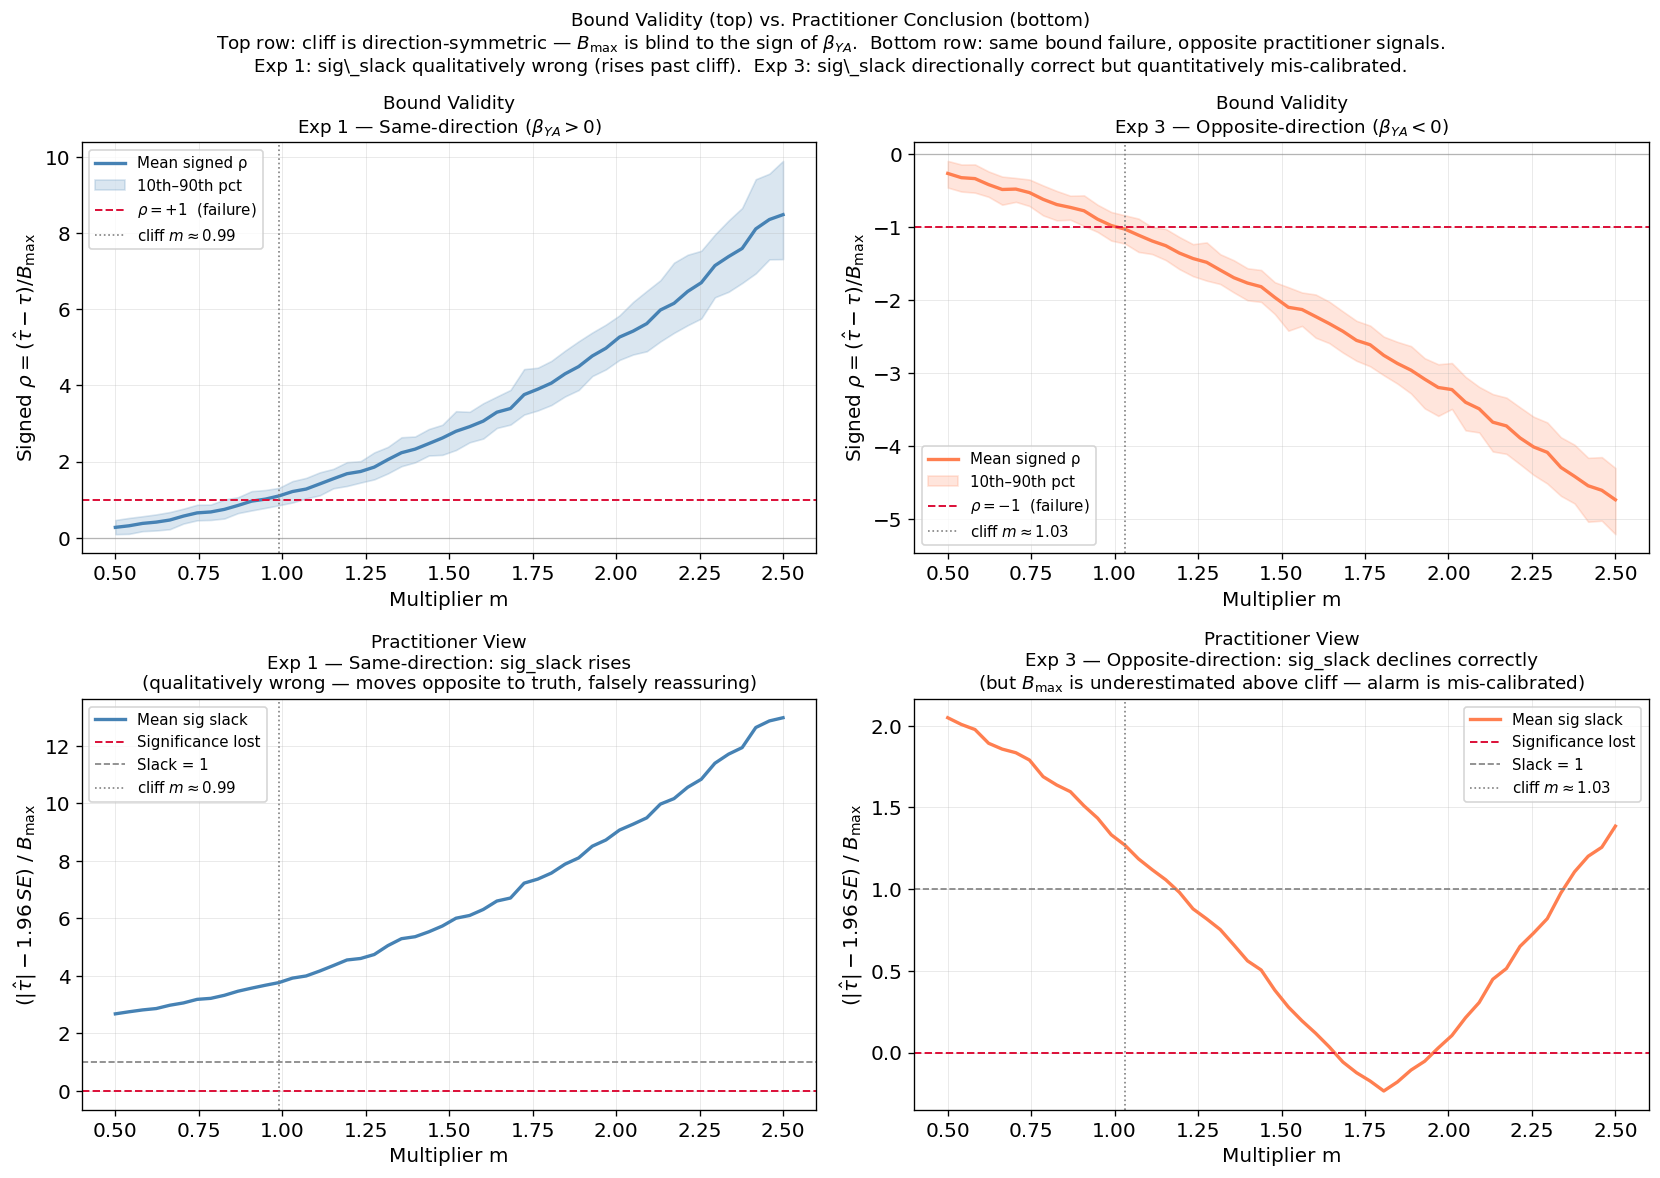

In [11]:
# ── Four-panel direction comparison ──────────────────────────────────────────
# Load Exp 1 (same-direction) results to pair with Exp 3 (opposite-direction).
# Requires experiment_01_baseline.ipynb to have been re-run after adding signed_rho.
try:
    r1 = np.load('results/experiment_01_results.npy', allow_pickle=True).item()
    if 'mean_signed_rho' not in r1:
        raise KeyError("mean_signed_rho not in Exp 1 results — re-run experiment_01_baseline.ipynb first")
except FileNotFoundError:
    raise FileNotFoundError("results/experiment_01_results.npy not found — run experiment_01_baseline.ipynb first")

r3_m   = np.array(multipliers)
r3_sr  = np.array(mean_signed_rho)
r3_p10 = np.array(p10_signed_rho)
r3_p90 = np.array(p90_signed_rho)
r3_ss  = np.array(mean_sig_slack)

cliff1 = r1['multipliers'][next((i for i, c in enumerate(r1['coverage']) if c < 50),
                                 len(r1['multipliers']) - 1)]
cliff3 = multipliers[next((i for i, c in enumerate(coverage) if c < 50),
                           len(multipliers) - 1)]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Row 1: Bound validity (signed ρ) ─────────────────────────────────────────
ax = axes[0, 0]
ax.plot(r1['multipliers'], r1['mean_signed_rho'], linewidth=2, color='steelblue',
        label='Mean signed ρ')
ax.fill_between(r1['multipliers'], r1['p10_signed_rho'], r1['p90_signed_rho'],
                alpha=0.2, color='steelblue', label='10th–90th pct')
ax.axhline(+1.0, linestyle='--', color='crimson', linewidth=1.2,
           label=r'$\rho = +1$  (failure)')
ax.axhline( 0.0, linestyle='-',  color='gray',    linewidth=0.8, alpha=0.5)
ax.axvline(cliff1, linestyle=':', color='gray', linewidth=1.0,
           label=f'cliff $m\\approx{cliff1:.2f}$')
ax.set_title('Bound Validity\nExp 1 — Same-direction ($\\beta_{YA} > 0$)', fontsize=11)
ax.set_xlabel('Multiplier m')
ax.set_ylabel(r'Signed $\rho = (\hat{\tau} - \tau) / B_{\max}$')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.plot(r3_m, r3_sr, linewidth=2, color='coral', label='Mean signed ρ')
ax.fill_between(r3_m, r3_p10, r3_p90, alpha=0.2, color='coral', label='10th–90th pct')
ax.axhline(-1.0, linestyle='--', color='crimson', linewidth=1.2,
           label=r'$\rho = -1$  (failure)')
ax.axhline( 0.0, linestyle='-',  color='gray',    linewidth=0.8, alpha=0.5)
ax.axvline(cliff3, linestyle=':', color='gray', linewidth=1.0,
           label=f'cliff $m\\approx{cliff3:.2f}$')
ax.set_title('Bound Validity\nExp 3 — Opposite-direction ($\\beta_{YA} < 0$)', fontsize=11)
ax.set_xlabel('Multiplier m')
ax.set_ylabel(r'Signed $\rho = (\hat{\tau} - \tau) / B_{\max}$')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── Row 2: Practitioner view (sig_slack) ─────────────────────────────────────
ax = axes[1, 0]
ax.plot(r1['multipliers'], r1['mean_sig_slack'], linewidth=2, color='steelblue',
        label='Mean sig slack')
ax.axhline(0.0, linestyle='--', color='crimson', linewidth=1.2, label='Significance lost')
ax.axhline(1.0, linestyle='--', color='gray',    linewidth=1.0, label='Slack = 1')
ax.axvline(cliff1, linestyle=':', color='gray', linewidth=1.0,
           label=f'cliff $m\\approx{cliff1:.2f}$')
ax.set_title(
    'Practitioner View\n'
    'Exp 1 — Same-direction: sig_slack rises\n'
    '(qualitatively wrong — moves opposite to truth, falsely reassuring)',
    fontsize=11)
ax.set_xlabel('Multiplier m')
ax.set_ylabel(r'$(|\hat{\tau}| - 1.96\,SE) \;/\; B_{\max}$')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.plot(r3_m, r3_ss, linewidth=2, color='coral', label='Mean sig slack')
ax.axhline(0.0, linestyle='--', color='crimson', linewidth=1.2, label='Significance lost')
ax.axhline(1.0, linestyle='--', color='gray',    linewidth=1.0, label='Slack = 1')
ax.axvline(cliff3, linestyle=':', color='gray', linewidth=1.0,
           label=f'cliff $m\\approx{cliff3:.2f}$')
ax.set_title(
    'Practitioner View\n'
    'Exp 3 — Opposite-direction: sig_slack declines correctly\n'
    r'(but $B_{\max}$ is underestimated above cliff — alarm is mis-calibrated)',
    fontsize=11)
ax.set_xlabel('Multiplier m')
ax.set_ylabel(r'$(|\hat{\tau}| - 1.96\,SE) \;/\; B_{\max}$')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle(
    'Bound Validity (top) vs. Practitioner Conclusion (bottom)\n'
    r'Top row: cliff is direction-symmetric — $B_{\max}$ is blind to the sign of $\beta_{YA}$.  '
    'Bottom row: same bound failure, opposite practitioner signals.\n'
    r'Exp 1: sig\_slack qualitatively wrong (rises past cliff).  '
    r'Exp 3: sig\_slack directionally correct but quantitatively mis-calibrated.',
    fontsize=11
)
plt.tight_layout()
plt.savefig('figures/experiment_direction_comparison.png', bbox_inches='tight')
plt.show()

## Interpretation

### Cliff symmetry — a tentative claim

Compare the vertical dotted lines in the top row.  The cliff multiplier in Exp 1 is $m \approx
0.99$ and in Exp 3 is $m \approx 1.03$ — a gap of ~0.04, which equals one grid step in the
multiplier sweep.  Two readings are possible:

- **Monte Carlo noise:** with $n_{\text{trials}} = 100$ and a coarse grid, a gap of one step
  is within sampling variability and consistent with the cliffs being equal.
- **Real effect:** negating $\beta_{YA}$ changes $Y$'s residual variance structure, and $S^2$
  enters the bias bound formula, so the two cliffs need not be algebraically identical even
  when $|\beta_{YA}|$ is matched.

The "cliff symmetry" claim — that $B^2 = C_Y^2 \cdot C_D^2 \cdot S^2$ depends only on
squared partial $R^2$s and is therefore direction-insensitive — is theoretically correct when
$S^2$ and the partial $R^2$s are the same in both experiments.  But the sign flip of
$\beta_{YA}$ does shift the $C_Y^2$ values of the LOO mocks upward (from $\approx 0.13$ to
$\approx 0.20$, visible in the contour plots), which means $S^2$ is also slightly different.
The claim is not straightforwardly confirmed by these numbers.  A paired replication — holding
$(X, A, \varepsilon)$ fixed and only flipping $\beta_{YA}$ across trials — would resolve this.

### The signed-ρ plots are not mirror images (asymmetry finding)

At $m = 2.5$, Exp 1 reaches signed $\rho \approx +8.5$ while Exp 3 reaches only $-4.7$ — the
same $|\beta_{YA}|$ produces nearly **2× more upward inflation than downward attenuation**.
This is a genuine asymmetry.  The mechanism: same-direction confounding compounds (OVB grows as
$|\beta_{DA} \cdot \beta_{YA}|$ *and* $Y$'s residual variance grows as both effects push the
same way), while opposite-direction confounding partially cancels in the residual structure.
The four-panel figure shows a near-mirror locally at the cliff, where the geometry is
approximately symmetric, but the global escalation in signed $\rho$ is meaningfully
asymmetric — a finding the current framing does not highlight.

### What the top row shows (bound validity)

The signed $\rho$ curves are near-reflections across zero at the cliff: Exp 1 rises through
$+1$; Exp 3 falls through $-1$.  Both encode the same information as coverage — $|\rho| > 1
\Leftrightarrow$ bound violated — but the sign makes the direction of bias legible without
additional metadata.

### What the bottom row shows (practitioner view)

The two `sig_slack` curves move in opposite directions under the same bound-violation event.

**Exp 1 (same-direction):** Positive confounding inflates $\hat{\tau}$, so $|\hat{\tau}|$
grows, the lower confidence limit moves away from zero, and `sig_slack` rises.  The
practitioner is increasingly reassured while the bound is already violated.  The metric moves
*opposite* to the truth — it is **qualitatively wrong**.

**Exp 3 (opposite-direction):** Negative confounding shrinks $\hat{\tau}$ toward zero, so
`sig_slack` declines.  The practitioner's alarm has **correct directional content**.  What is
wrong is not the alarm itself but its *quantitative calibration*: the alarm is expressed as a
multiple of $B_{\max}$, which the top row shows is underestimated above the cliff.  So the
practitioner gets the right signal for the wrong quantitative reason.

### The sig_slack U-shape: a structural failure mode

Past $m \approx 1.65$, `sig_slack` reverses and climbs again, eventually crossing 1.0 a second
time at $m \approx 2.35$.  This is not noise.  Once downward bias is so strong that $\hat{\tau}$
crosses zero and goes negative, $|\hat{\tau}|$ starts growing again — and with the `abs()` in
the formula, `sig_slack` rises to falsely-reassuring levels.  The metric cannot distinguish "I
have a strong positive effect" from "I have a strongly negative effect that I am now treating as
positive against the null."  A sign-aware version — $(\hat{\tau} - 1.96 \cdot SE) / B_{\max}$
— would stay negative past the crossing point and correctly flag the sign inversion.

### Two different failure modes from the same metric

| | Exp 1 (same-direction $\beta_{YA} > 0$) | Exp 3 (opposite-direction $\beta_{YA} < 0$) |
|---|---|---|
| **Bound validity** (top row) | Cliff at $m \approx 0.99$ | Cliff at $m \approx 1.03$ |
| **sig_slack direction** | Rises — *qualitatively wrong* | Falls then rebounds — *directionally right, then wrong* |
| **sig_slack calibration** | Grows against broken $B_{\max}$ → false reassurance | Mis-calibrated above cliff; U-shape past sign inversion |

`sig_slack` is not uniformly broken — the failure is **direction-asymmetric** and has a
qualitatively distinct second failure mode (U-shape) that only appears under opposite-direction
confounding strong enough to flip the estimate's sign.